
# RealNVP on 2D Data (Spiral & Gaussian Mixture) vs Simple MLP Regression

**Goal:** Implement a minimal **Normalizing Flow** (RealNVP) for **2D density modeling** and compare it with a **simple MLP regression** that predicts the conditional mean \( \mathbb{E}[Y\mid X] \).  
This notebook demonstrates why **generative modeling** is necessary for multi-modal or highly non-linear 2D distributions, where a mean-regression collapses information.

## Contents
1. Data generators (2D spiral, 2D Gaussian mixture)
2. RealNVP (PyTorch) + maximum likelihood training
3. Sampling & log-likelihood evaluation
4. Simple MLP regression (predicting `y` from `x`) + RMSE
5. Visual comparison



## 1. Environment
We use **PyTorch**, **NumPy**, and **matplotlib**. 


In [10]:

import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = np.random.default_rng(42)
torch.manual_seed(42)
np.random.seed(42)



## 2. Data Generators (2D)
We implement two synthetic datasets:
- **Spiral**: Highly non-linear & single-valued only in polar coordinates; multi-valued in Cartesian conditional views.
- **Gaussian Mixture Model (GMM)**: Multi-modal distribution with several Gaussian components.


In [11]:

def make_spiral(n=4000, noise=0.1, revolutions=2.0, radius=1.0, seed=0):
    """Generate a 2D spiral dataset.
    
    Args:
        n: number of points
        noise: isotropic Gaussian noise std
        revolutions: number of spiral turns
        radius: final radius scale
        seed: RNG seed
    Returns:
        X: (n, 2) numpy array
    """
    rng = np.random.default_rng(seed)
    t = rng.uniform(0, 1, size=n)
    theta = 2 * math.pi * revolutions * t
    r = radius * t
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    data = np.stack([x, y], axis=1)
    data += rng.normal(0, noise, size=data.shape)
    return data.astype(np.float32)

def make_gmm_2d(n=4000, centers=None, covs=None, probs=None, seed=0):
    """Generate a 2D Gaussian mixture dataset.
    
    Args:
        n: number of points
        centers: list of 2D means
        covs: list of 2x2 covariance matrices
        probs: mixture probabilities
        seed: RNG seed
    Returns:
        X: (n, 2) numpy array
    """
    rng = np.random.default_rng(seed)
    if centers is None:
        centers = [np.array([0.0, 0.0]), np.array([2.5, 2.5]), np.array([-2.5, 2.5])]
    if covs is None:
        covs = [np.array([[0.3, 0.0],[0.0, 0.3]]),
                np.array([[0.4, 0.1],[0.1, 0.3]]),
                np.array([[0.3, -0.05],[-0.05, 0.4]])]
    k = len(centers)
    if probs is None:
        probs = np.ones(k) / k
    comps = rng.choice(k, size=n, p=probs)
    data = np.zeros((n, 2), dtype=np.float32)
    for i, c in enumerate(comps):
        data[i] = rng.multivariate_normal(centers[c], covs[c]).astype(np.float32)
    return data

# Quick preview generation (disabled by default to keep cell outputs clean)
# X_spiral = make_spiral(n=2000, noise=0.05, revolutions=2.5, radius=2.0, seed=1)
# X_gmm = make_gmm_2d(n=2000, seed=1)
# print(X_spiral.shape, X_gmm.shape)



## 3. RealNVP (PyTorch)
We implement a minimal RealNVP for 2D:
- Alternating binary masks (\([1,0]\) and \([0,1]\)).
- Each coupling layer uses a small MLP to output scale \(s(\cdot)\) and shift \(t(\cdot)\).
- Base distribution: standard Gaussian.
- Training objective: **maximum likelihood** (negative log-likelihood minimization).


In [13]:

class STNet(nn.Module):
    """Tiny MLP that outputs scale s and shift t for coupling."""
    def __init__(self, in_dim=1, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2*out_dim)  # output both s and t
        )
    def forward(self, x):
        st = self.net(x)
        s, t = torch.chunk(st, 2, dim=-1)
        # clamp scale for stability
        s = torch.tanh(s)
        return s, t

class CouplingLayer(nn.Module):
    def __init__(self, mask, hidden=64):
        super().__init__()
        self.register_buffer('mask', mask)
        # input dim is 2; masked dim -> conditioner input size is 1
        self.st_net = STNet(in_dim=1, hidden=hidden, out_dim=1)
    def forward(self, x):
        x1 = x * self.mask
        x2 = x * (1 - self.mask)
        # Conditioner uses the kept dimension
        cond = x1.sum(dim=1, keepdim=True)  # since mask selects exactly one dim
        s, t = self.st_net(cond)
        y2 = (x2 - t) * torch.exp(-s)
        y = x1 + y2
        log_det = -s.squeeze(-1)  # log|det J| for this coupling
        return y, log_det
    def inverse(self, y):
        y1 = y * self.mask
        y2 = y * (1 - self.mask)
        cond = y1.sum(dim=1, keepdim=True)
        s, t = self.st_net(cond)
        x2 = y2 * torch.exp(s) + t
        x = y1 + x2
        log_det = s.squeeze(-1)
        return x, log_det

class RealNVP(nn.Module):
    def __init__(self, n_coupling=6, hidden=64):
        super().__init__()
        masks = []
        # alternate masks [1,0] and [0,1] for 2D
        for i in range(n_coupling):
            if i % 2 == 0:
                masks.append(torch.tensor([1.0, 0.0]))
            else:
                masks.append(torch.tensor([0.0, 1.0]))
        self.layers = nn.ModuleList([CouplingLayer(mask=m.view(1,2), hidden=hidden) for m in masks])
        self.base = torch.distributions.MultivariateNormal(
            loc=torch.zeros(2), covariance_matrix=torch.eye(2)
        )
    def f(self, x):
        log_det_sum = torch.zeros(x.size(0), device=x.device)
        z = x
        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det
        return z, log_det_sum
    def f_inv(self, z):
        log_det_sum = torch.zeros(z.size(0), device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, log_det = layer.inverse(x)
            log_det_sum += log_det
        return x, log_det_sum
    def log_prob(self, x):
        z, log_det = self.f(x)
        log_pz = self.base.log_prob(z)
        return log_pz + log_det
    def sample(self, n):
        with torch.no_grad():
            z = self.base.sample((n,)).to(next(self.parameters()).device)
            x, _ = self.f_inv(z)
            return x



### Training Utilities


In [14]:

def train_flow(model, data, epochs=1000, batch_size=256, lr=1e-3, verbose_every=100):
    model.to(device)
    x = torch.from_numpy(data).float().to(device)
    ds = TensorDataset(x)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    opt = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for ep in range(1, epochs+1):
        epoch_loss = 0.0
        for (xb,) in dl:
            opt.zero_grad()
            # maximize log-likelihood -> minimize negative log-likelihood
            nll = -model.log_prob(xb).mean()
            nll.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            epoch_loss += nll.item() * xb.size(0)
        epoch_loss /= len(ds)
        losses.append(epoch_loss)
        if verbose_every and ep % verbose_every == 0:
            print(f"[Flow] Epoch {ep:04d} | NLL: {epoch_loss:.4f}")
    return losses

def evaluate_flow_loglik(model, data):
    with torch.no_grad():
        x = torch.from_numpy(data).float().to(device)
        ll = model.log_prob(x).mean().item()
    return ll



## 4. Simple MLP Regression (Predicting y from x)
We fit a **regressor** \( \hat{y}(x) \) to minimize MSE on `y|x`.  
For multi-modal conditionals (e.g., spiral, mixture), the **conditional mean** is not representative of the distribution, hence large residuals and visually poor fit.


In [17]:

class MLPRegressor(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_mlp_regressor(X, epochs=500, batch_size=256, lr=1e-3, verbose_every=100):
    # X is (n,2): predict y from x
    x1 = torch.from_numpy(X[:, [0]]).float().to(device)
    y = torch.from_numpy(X[:, [1]]).float().to(device)
    ds = TensorDataset(x1, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    model = MLPRegressor().to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for ep in range(1, epochs+1):
        epoch_loss = 0.0
        for xb, yb in dl:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(ds)
        losses.append(epoch_loss)
        if verbose_every and ep % verbose_every == 0:
            print(f"[MLP] Epoch {ep:04d} | MSE: {epoch_loss:.4f}")
    return model, losses

def evaluate_mlp_rmse(model, X):
    x1 = torch.from_numpy(X[:, [0]]).float().to(device)
    y = torch.from_numpy(X[:, [1]]).float().to(device)
    with torch.no_grad():
        pred = model(x1)
        rmse = torch.sqrt(((pred - y)**2).mean()).item()
    return rmse



## 5. Training & Visual Comparison Helpers
- Train RealNVP on the selected dataset; plot training curve and generated samples.
- Train MLP regressor (y|x); plot predicted mean curve over a grid.


In [18]:

def plot_scatter(X, title):
    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(X[:,0], X[:,1], s=6, alpha=0.6)
    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
    plt.show()

def plot_losses(losses, title):
    plt.figure(figsize=(6, 3.5))
    plt.plot(losses)
    plt.title(title)
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(True)
    plt.show()

def plot_flow_samples(model, n=2000, title="Flow Samples"):
    with torch.no_grad():
        samples = model.sample(n).detach().cpu().numpy()
    plot_scatter(samples, title)

def plot_mlp_curve(model, X, title="MLP regression y|x"):
    # sort by x for a clean line plot
    xs = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 400).astype(np.float32).reshape(-1,1)
    with torch.no_grad():
        pred = model(torch.from_numpy(xs).float().to(device)).cpu().numpy().reshape(-1)
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:,0], X[:,1], s=5, alpha=0.4, label="data")
    plt.plot(xs.reshape(-1), pred, linewidth=2.0, label="MLP mean(y|x)")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.grid(True); plt.legend()
    plt.show()



## 6. Experiment 1 — Spiral
"""
- Train flow for density modeling
- Train MLP regressor (y|x)
- Compare: flow log-likelihood vs MLP RMSE and visualization
"""


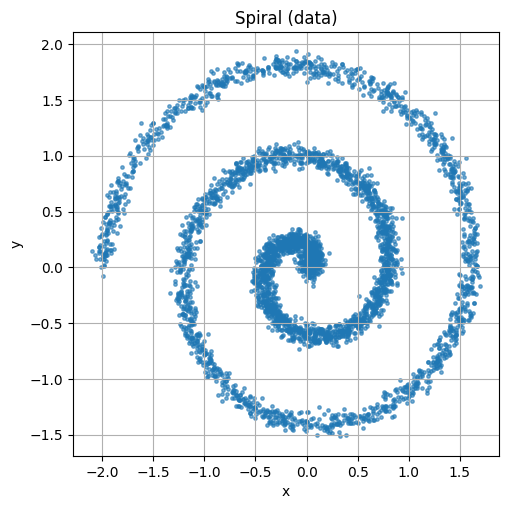

[Flow] Epoch 0200 | NLL: -4.1348
[Flow] Epoch 0400 | NLL: -4.1519
[Flow] Epoch 0600 | NLL: -4.1619


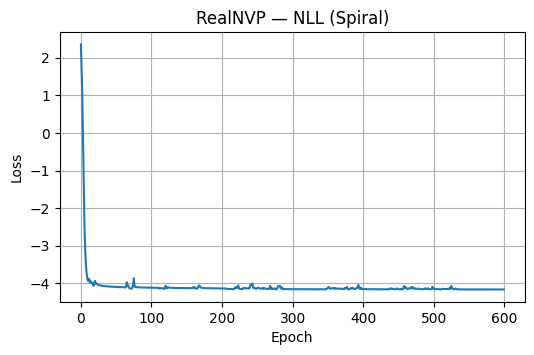

[Spiral] Flow test log-likelihood: 4.162


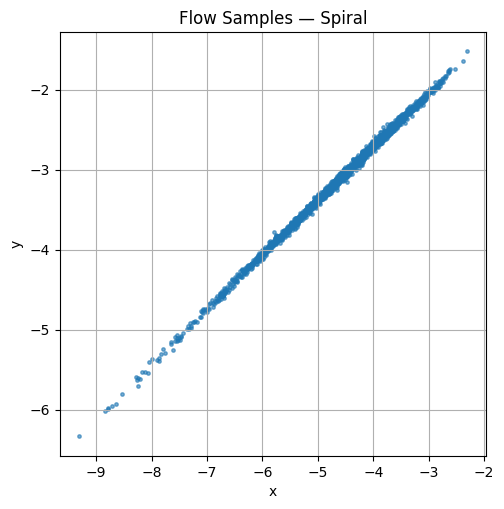

[MLP] Epoch 0200 | MSE: 0.6130
[MLP] Epoch 0400 | MSE: 0.6104


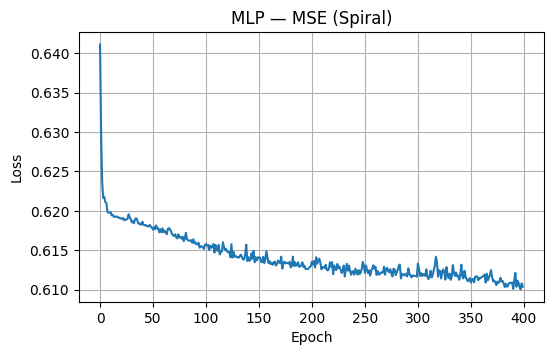

[Spiral] MLP test RMSE (y|x): 0.791


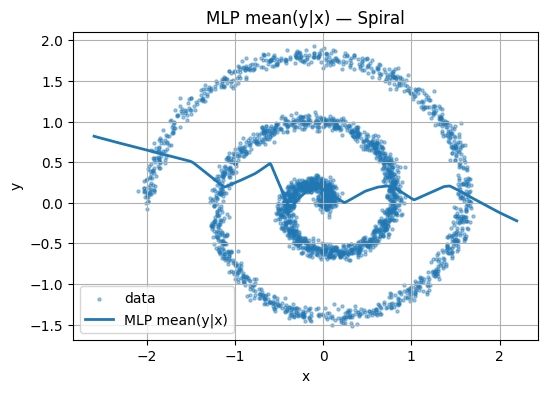

In [19]:

# Generate data
X_spiral = make_spiral(n=4000, noise=0.05, revolutions=2.5, radius=2.0, seed=10)
plot_scatter(X_spiral, "Spiral (data)")

# Split
idx = np.arange(len(X_spiral))
rng = np.random.default_rng(123)
rng.shuffle(idx)
train_idx = idx[:3000]
test_idx  = idx[3000:]
Xtr, Xte = X_spiral[train_idx], X_spiral[test_idx]

# Train RealNVP
flow = RealNVP(n_coupling=6, hidden=64)
flow_losses = train_flow(flow, Xtr, epochs=600, batch_size=512, lr=1e-3, verbose_every=200)
plot_losses(flow_losses, "RealNVP — NLL (Spiral)")
ll_te = evaluate_flow_loglik(flow, Xte)
print(f"[Spiral] Flow test log-likelihood: {ll_te:.3f}")
plot_flow_samples(flow, n=2000, title="Flow Samples — Spiral") 

# Train MLP regression y|x
mlp, mlp_losses = train_mlp_regressor(Xtr, epochs=400, batch_size=512, lr=1e-3, verbose_every=200)
plot_losses(mlp_losses, "MLP — MSE (Spiral)")
rmse_spiral = evaluate_mlp_rmse(mlp, Xte)
print(f"[Spiral] MLP test RMSE (y|x): {rmse_spiral:.3f}")
plot_mlp_curve(mlp, Xtr, title="MLP mean(y|x) — Spiral")



## 7. Experiment 2 — Gaussian Mixture
"""
Repeat the same procedure on a multi-modal Gaussian mixture.
"""


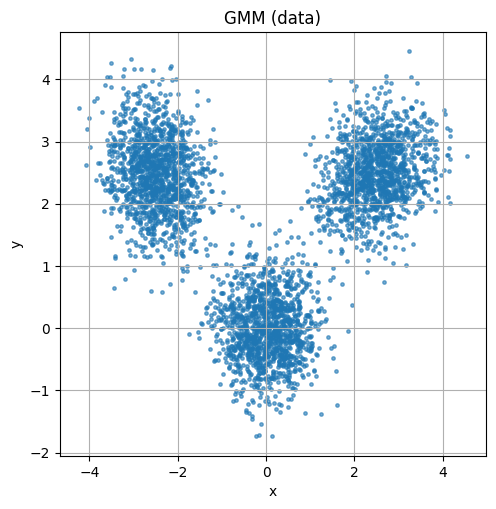

[Flow] Epoch 0200 | NLL: -4.1419
[Flow] Epoch 0400 | NLL: -4.1616
[Flow] Epoch 0600 | NLL: -4.1620


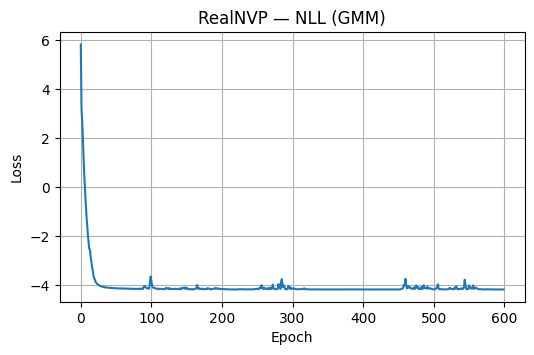

[GMM] Flow test log-likelihood: 4.162


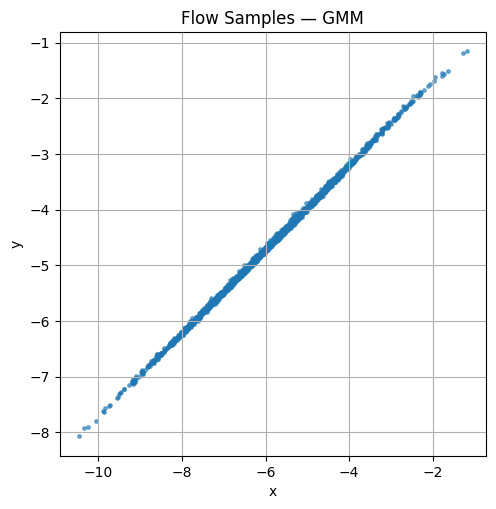

[MLP] Epoch 0200 | MSE: 0.3791
[MLP] Epoch 0400 | MSE: 0.3771


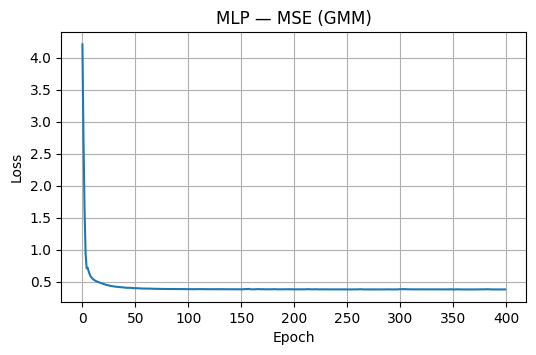

[GMM] MLP test RMSE (y|x): 0.604


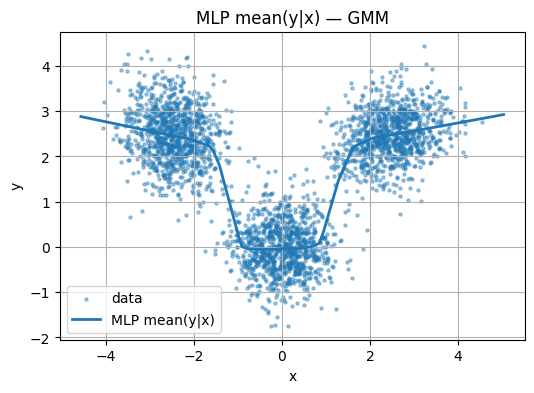

In [20]:

# Generate data
X_gmm = make_gmm_2d(n=4000, seed=22)
plot_scatter(X_gmm, "GMM (data)")

# Split
idx = np.arange(len(X_gmm))
rng = np.random.default_rng(456)
rng.shuffle(idx)
train_idx = idx[:3000]
test_idx  = idx[3000:]
Xtr, Xte = X_gmm[train_idx], X_gmm[test_idx]

# Train RealNVP
flow = RealNVP(n_coupling=6, hidden=64)
flow_losses = train_flow(flow, Xtr, epochs=600, batch_size=512, lr=1e-3, verbose_every=200)
plot_losses(flow_losses, "RealNVP — NLL (GMM)")
ll_te = evaluate_flow_loglik(flow, Xte)
print(f"[GMM] Flow test log-likelihood: {ll_te:.3f}")
plot_flow_samples(flow, n=2000, title="Flow Samples — GMM") 

# Train MLP regression y|x
mlp, mlp_losses = train_mlp_regressor(Xtr, epochs=400, batch_size=512, lr=1e-3, verbose_every=200)
plot_losses(mlp_losses, "MLP — MSE (GMM)")
rmse_gmm = evaluate_mlp_rmse(mlp, Xte)
print(f"[GMM] MLP test RMSE (y|x): {rmse_gmm:.3f}")
plot_mlp_curve(mlp, Xtr, title="MLP mean(y|x) — GMM")



## 8. Notes & Takeaways
- **RealNVP** learns the **full 2D density** and can sample realistic points; its performance is measured via **log-likelihood** on held-out data.
- **MLP regression** only learns the **conditional mean** \( \hat{y}(x) \); it often **collapses** multi-modal structure (e.g., mixture components, spiral arcs) into a single mean path.
- Consequently, generative modeling is **worth it** whenever we need full **uncertainty** and **multi-modality** (simulation, risk, counterfactuals), or when the target is **not a function** of inputs.
